2025-09-23 11:53:15.896981: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-23 11:53:15.897314: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-23 11:53:15.939214: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-23 11:53:16.978410: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

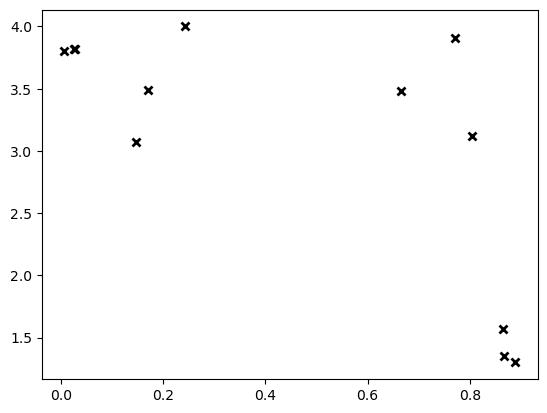

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import gpflow

X = np.array(
    [
        [0.865], [0.666], [0.804], [0.771], [0.147], [0.866], [0.007], [0.026],
        [0.171], [0.889], [0.243], [0.028],
    ]
)
Y = np.array(
    [
        [1.57], [3.48], [3.12], [3.91], [3.07], [1.35], [3.80], [3.82], [3.49],
        [1.30], [4.00], [3.82],
    ]
)

plt.plot(X, Y, "kx", mew=2)

In [2]:
model = gpflow.models.GPR(
    (X, Y),
    kernel=gpflow.kernels.SquaredExponential(),
)

E0000 00:00:1758609679.706695   26157 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1758609679.764783   26157 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
opt = gpflow.optimizers.Scipy()
opt.minimize(model.training_loss, model.trainable_variables)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 16.45115183214254
        x: [-7.928e-01  1.165e+01 -1.305e+00]
      nit: 18
      jac: [ 4.735e-06 -5.010e-07  2.479e-05]
     nfev: 24
     njev: 24
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [4]:
Xnew = np.array([[0.5]])
model.predict_f(Xnew)

(<tf.Tensor: shape=(1, 1), dtype=float64, numpy=array([[4.28009566]])>,
 <tf.Tensor: shape=(1, 1), dtype=float64, numpy=array([[0.30584767]])>)

/tmp/ipykernel_26157/2947285204.py:6: RuntimeWarning: invalid value encountered in sqrt
  f_lower = f_mean - 1.96 * np.sqrt(f_var)
/tmp/ipykernel_26157/2947285204.py:7: RuntimeWarning: invalid value encountered in sqrt
  f_upper = f_mean + 1.96 * np.sqrt(f_var)


ValueError: x and y must have same first dimension, but have shapes (100, 1) and (1, 100, 100)

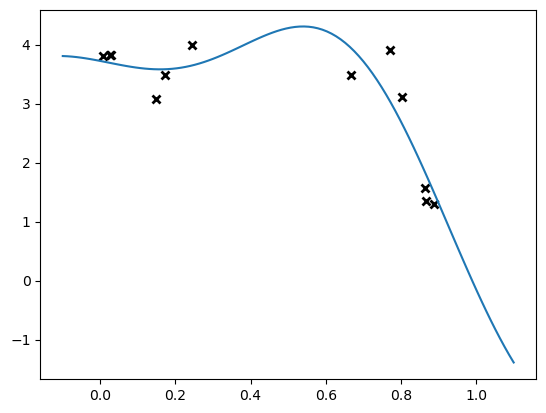

In [ ]:
Xplot = np.linspace(-0.1, 1.1, 100)[:, None]

f_mean, f_var = model.predict_f(Xplot, full_cov=False)
y_mean, y_var = model.predict_y(Xplot)

f_lower = f_mean - 1.96 * np.sqrt(f_var)
f_upper = f_mean + 1.96 * np.sqrt(f_var)
y_lower = y_mean - 1.96 * np.sqrt(y_var)
y_upper = y_mean + 1.96 * np.sqrt(y_var)

plt.plot(X, Y, "kx", mew=2, label="input data")
plt.plot(Xplot, f_mean, "-", color="C0", label="mean")
plt.plot(Xplot, f_lower, "--", color="C0", label="f 95% confidence")
plt.plot(Xplot, f_upper, "--", color="C0")
plt.fill_between(
    Xplot[:, 0], f_lower[:, 0], f_upper[:, 0], color="C0", alpha=0.1
)
plt.plot(Xplot, y_lower, ".", color="C0", label="Y 95% confidence")
plt.plot(Xplot, y_upper, ".", color="C0")
plt.fill_between(
    Xplot[:, 0], y_lower[:, 0], y_upper[:, 0], color="C0", alpha=0.1
)
plt.legend()